# Domača Naloga 3

## Naloga 1: Nenadzorovano učenje in predprocesiranje podatkov

### 1.a: Identifikacija povezovalnega kriterija

Spodaj so trije dendrogrami, narejeni na isti podatkovni množici, vsak z drugo funkcijo združevanja (linkage): enojno (single), celovito (complete) in Wardovo. Določi, kateri dendrogram je bil pridobljen s katero funkcijo. Vsako izbiro funkcije utemelji z vsaj eno konkretno značilnostjo dendrograma (ne zgolj z imenom funkcije ali dendrograma).

![dendrogrami](1a_dendrogrami.png)

**Vprašanji:** 
- Če bi dendrogram C odrezal/a tako, da bi dobil/a natanko tri (3) skupine, ali bi bile velikosti dobljenih skupin bolj ali manj uravnotežene kot pri istem prerezu dendrograma A? 
- Pojasni, zakaj Wardov kriterij teži k (po velikosti) bolj uravnoteženim skupinam.

**Pari, pojasnila in odgovora:**

- **Dendrogram A = single linkage (enojno povezovanje)**
  - Single linkage meri razdaljo med dvema skupinama kot razdaljo med njunima najbližjima točkama.
  - To pomeni, da se lahko dve skupini združita že zato, ker je ena sama točka iz prve skupine blizu eni sami točki iz druge skupine. Prav zato single linkage pogosto povzroči t. i. **veriženje** oziroma **chaining effect**: gruče se lepijo ena na drugo postopoma, kot veriga.
  - Pri dendrogramu A se to lepo vidi: veliko združitev se zgodi pri zelo majhnih razdaljah, večina vej se združuje nizko, ena skupina pa se šele zelo pozno priključi ostalim. Celotna struktura je zato precej neuravnotežena.
  - Posebej značilno je, da se ena veja na levi z ostalimi združi šele zelo visoko, medtem ko se desni večji del združuje bolj postopno.

- **Dendrogram B = complete linkage (celovito povezovanje)**
  - Complete linkage meri razdaljo med dvema skupinama kot razdaljo med najbolj oddaljenima točkama iz teh dveh skupin.
  - Zato complete linkage običajno dela bolj kompaktne skupine kot single linkage. Skupine niso tako verižne, ampak bolj **stisnjene skupaj**.
  - Pri dendrogramu B opazimo, da se združevanja dogajajo pri večjih razdaljah kot pri A, struktura ni tako verižna kot pri A, skupine se združujejo bolj previdno in so višine združevanj bolj razporejene po srednjem območju.

- **Dendrogram C = Wardovo povezovanje**
  - Wardova metoda pri vsakem koraku združi tisti dve skupini, pri katerih se najmanj poveča notranja razpršenost.
  - Zato Wardova metoda pogosto naredi bolj kompaktne in bolj uravnotežene skupine, pri zadnjih združitvah pa se pogosto pojavijo veliki skoki.
  - Pri dendrogramu C je to najbolj očitno: zadnje združitve so pri zelo velikih višinah, najvišja združitev je okoli 30, kar je bistveno več kot pri A in B, struktura je bolj razdeljena na več večjih, smiselnih blokov, glavne veje pa so bolj uravnotežene kot pri A.
  

**Odgovor na dodatno vprašanje:**
Če dendrogram C odrežemo tako, da dobimo natanko tri skupine, bodo velikosti skupin praviloma bolj uravnotežene kot pri dendrogramu A. Dendrogram A zaradi single linkage kaže veriženje, zato lahko pri prerezu dobimo manj enakomerno velike skupine.

**Zakaj Ward teži k bolj uravnoteženim skupinam?**
Wardov kriterij teži k bolj uravnoteženim skupinam, ker pri združevanju minimizira povečanje notranje razpršenosti. Združevanje zelo različnih ali zelo neenakomerno velikih skupin bi običajno močno povečalo vsoto kvadratov razdalj znotraj skupin, zato Ward raje združuje kompaktne in primerljivo velike skupine.

### 1.b: Izbira števila skupin — komolec proti silhueti

Spodaj so prikazani podatki (levo), pripadajoči komolčni diagram (inercija $K$-Means glede na število skupin $K$) in graf vrednosti silhuet glede na $K$:

![izbira K](1b_k_izbira.png)

Heuristiki za izbiro števila skupin kažeta v različno smer: komolec sugerira eno vrednost $K$, silhueta drugo.

**Vprašanja:**

- Iz vsakega diagrama (komolec in silhuete) odčitaj priporočeno vrednost $K$. Pojasni, zakaj se vrednosti razhajata: kaj v strukturi teh podatkov povzroči razkorak?
- Pojasni, kdaj lahko silhueta za posamezen primer postane negativna. Kaj to konkretno pove o tistem primeru in celotnem razvrščanju v skupine.
- Katero vrednost $K$ bi sam/a izbral/a, če bi videl/a samo komolčni in samo silhuetni diagram (brez scatter plota diagrama podatkov)? Kaj bi naredil/a, če bi imel/a tudi scatter plot, pa bi vseeno hotel/a podpreti kvantitativno odločitev? (Namig: premisli o hierarhični strukturi, ki je prisotna pri razvrščanju teh podatkov.)

**Odgovori:**

- Metoda komolca predlaga (K=6), saj se inercija do te vrednosti močno zmanjšuje, po (K=6) pa se krivulja skoraj poravna. Metoda silhuete ima najvišjo vrednost pri (K=2), zato bi glede na največjo silhueto izbrali (K=2). Razlika nastane zato, ker imajo podatki hierarhično strukturo: na grobi ravni sta vidni dve veliki skupini, znotraj njiju pa še šest manjših naravnih skupin. Zato silhueta dobro oceni grobo delitev na dve skupini, komolec pa bolje zazna podrobnejšo delitev na šest skupin.
- Silhueta posamezne točke je negativna takrat, ko je točka v povprečju bližje neki drugi gruči kot svoji lastni gruči. To pomeni, da je točka verjetno napačno razvrščena ali pa leži na meji med dvema gručama. Če ima veliko točk negativno silhueto, je izbrano število gruč ali sama razvrstitev verjetno neustrezna.
- V tem primeru bi izbrali (K=6), ker scatter plot jasno kaže šest manjših, dobro ločenih skupin. To izbiro podpira tudi metoda komolca, saj se inercija po (K=6) skoraj ne zmanjšuje več. Čeprav ima silhueta največjo vrednost pri (K=2), ta izbira predstavlja le grobo delitev podatkov na dve veliki skupini. Ker želimo zajeti podrobnejšo strukturo podatkov, je (K=6) bolj smiselna izbira.

### 1.c: Lokalni minimumi pri K-Means

Spodaj so prikazana štiri gručenja s K-Means na isti podatkovni množici. Razlika med gručenji je nastala zgolj zaradi različnih postavitev začetnih centroidov (`init='random'`, `n_init=1`, različne nastavitve `random_state`, t.j., semena za generator naključnih števil). Naslov vsake slike vsebuje tudi inercijo (vsoto kvadratov razdalj do centroidov) za ustrezno gručenje.

![lokalni minimumi](1c_lokalne.png)

**Vprašanja:**

- Zgornja gručenja se razlikujejo. Pojasni razlike in dejstvo, da se tudi končne inercije, kljub konvergenci algoritma, medsebojno razlikujejo. Katero od štirih gručenj je glede na inercijo najboljše? Zakaj to ne pomeni, da je nujno tudi to razvrščanje prava izbira za to podatkovno množico?
- V praksi `KMeans` v `sklearn` uporablja privzete nastavitve `n_init=10` in `init='k-means++'`. Razišči in pojasni, kaj _K-Means++_ počne. Zakaj v večini primerov bistveno zmanjša verjetnost slabega končnega razvrščanja?
- Konstruiraj (ali besedno opiši) majhno podatkovno množico, kjer tudi K-Means++ z visokim `n_init` še vedno (v večini primerov) ne najde prave rešitve. Kakšna struktura podatkov to povzroči? (Namig: o teh primerih smo govorili tudi na vajah.)
- Predlagaj dve rešitvi, ki bi pravilno gručila podatke na zgornji sliki.

**Odgovori:**
- Gručenja se razlikujejo zato, ker je K-Means občutljiv na začetno postavitev centroidov. Ker je uporabljeno init='random' in n_init=1, algoritem pri različnih semenih začne iz različnih začetnih centroidov in lahko konča v različnih lokalnih minimumih. Zato se razlikujejo tudi končne inercije. Najboljše gručenje glede na inercijo je pri seed=1, kjer je inercija najnižja, približno 508.5. To pa ne pomeni nujno, da je to tudi prava vsebinska razvrstitev, saj K-Means minimizira samo vsoto kvadratov razdalj do centroidov in predpostavlja kompaktne, približno okrogle gruče.
- K-Means++ je pametnejši način izbire začetnih centroidov. Prvi centroid izbere naključno, naslednje pa z večjo verjetnostjo med točkami, ki so daleč od že izbranih centroidov. Tako so začetni centroidi bolje razporejeni po podatkih. Zaradi tega se zmanjša verjetnost, da bi več centroidov začelo v istem območju, nek drug del podatkov pa bi ostal brez centroida. Posledično K-Means++ običajno zmanjša možnost slabega lokalnega minimuma in vodi do boljšega končnega razvrščanja.
- Primer so podatki v obliki dveh lun ali koncentričnih krogov. Pri takih podatkih so naravne gruče ne-konveksne oziroma ukrivljene. K-Means pa podatke razvršča glede na najbližji centroid in zato oblikuje približno ravne meje med gručami. Tudi če začetne centroide izberemo s K-Means++ in uporabimo veliko ponovitev, metoda še vedno optimizira kriterij, ki predpostavlja kompaktne in približno okrogle gruče. Zato pri takšni strukturi podatkov pogosto ne najde prave naravne razdelitve.
- Prva rešitev je uporaba K-Means z boljšimi nastavitvami, na primer init='k-means++' in večjim n_init, saj s tem zmanjšamo vpliv slabe začetne postavitve centroidov. Druga rešitev je uporaba metode, ki bolje modelira podolgovate gruče, na primer Gaussian Mixture Model s polno kovariančno matriko. Ta metoda lahko opiše eliptične oziroma podolgovate skupine, zato je za take podatke primernejša od osnovnega K-Means.

### 1.d: Prekletstvo večrazsežnosti

Spodaj so prikazane porazdelitve evklidskih razdalj med vsemi pari $n = 300$ naključno (enakomerno) vzorčenih točk v $[0,1]^d$ za tri različne dimenzionalnosti prostora $d \in \{2,\ 20,\ 500\}$:

![curse of dim](1d_kletev.png)

V naslovih slik sta navedena povprečje in standardni odklon razdalj ter njuno razmerje $\text{std} / \text{povp}$.

**Vprašanja:**

- Z rastjo razsežnosti prostora, vrednost razmerje $\text{std}/\text{povp}$ strmo pada (s $\sim 0.48$ pri $d=2$ na $\sim 0.03$ pri $d=500$). Pojasni intuitivno, zakaj se to zgodi.
- Kako ta pojav vpliva na algoritmih K-Means, DBSCAN in klasifikacijo s KNN v zelo visokorazsežnostnih prostorih? Za vsakega od treh algoritmov identificiraj konkretno komponento, ki v teh prostorih postane praktično neuporabna in pojasni zakaj je temu tako.
- Pogosta strategija pred razvrščanjem visokorazsežnostnih podatkov je uporaba algoritmov za krčenje razsežnosti kot je PCA (npr. iz 500D v 10D), nato pa razvrščanje v skupine v skrčenem (nizkorazsežnostnem) podatkovnem prostoru. Pojasni kdaj taka strategija pomaga (kakšne so značilnosti podatkov, kjer PCA odkrije pravo strukturo) in kdaj škoduje (kjer PCA struktur, pomembnih za razvrščanje v skupine, ne najde).

**Odgovori:**
- Z rastjo dimenzije se evklidska razdalja računa kot vsota prispevkov iz vedno več koordinat. Ker so točke enakomerno naključno vzorčene, se ti prispevki pri velikem številu dimenzij povprečijo in razdalje se koncentrirajo okoli povprečne vrednosti. Zato povprečna razdalja raste, relativna razpršenost razdalj pa pada. Posledično so v visokih dimenzijah skoraj vse točke med seboj podobno oddaljene, zato pojma “bližnja” in “oddaljena” točka postaneta manj uporabna. 
- Vsi trije algoritmi temeljijo na razdaljah, zato jih koncentracija razdalj v visokih dimenzijah močno prizadene. Pri K-Means postane problematična dodelitev točk najbližjemu centroidu, ker so razdalje do centroidov lahko zelo podobne, in tudi inercija postane manj informativna. Pri DBSCAN postane problematična izbira $\epsilon$-okolice: pri premajhnem $\epsilon$ so točke označene kot šum, pri malo večjem pa se lahko preveč točk poveže v eno gručo. Pri KNN postane problematično iskanje najbližjih sosedov, saj najbližji sosed ni več bistveno bližje od ostalih, zato je klasifikacija manj zanesljiva.
- PCA pomaga, kadar imajo podatki nizko notranjo dimenzionalnost in je prava struktura gruč zajeta v smereh največje variance. Takrat PCA odstrani šumne dimenzije, ohrani glavni signal in lahko izboljša razvrščanje. PCA pa škoduje, kadar so za gručenje pomembne smeri z majhno varianco ali kadar je struktura podatkov nelinearna. Ker PCA ohranja predvsem smeri največje variance, lahko zavrže dimenzije, ki so ključne za ločevanje gruč, ali pa ne zazna ukrivljenih struktur, kot so dve luni ali koncentrični krogi.

## Naloga 2: Izbira napovednih spremenljivk z algoritmom ReliefF

V tej nalogi boš implementiral/a algoritem ReliefF, ki oceni pomembnost (napovedno moč) napovednih spremenljivk z analizo najbližjih sosedov: tistih z isto vrednostjo ciljne spremenljivke (*nearest hits*) in tistih z različno vrednostjo ciljne spremenljivke (*nearest misses*). Logična predpostavka algoritma je, da dobra napovedna spremenljivka ima podobne vrednosti v primerih z isto vrednostjo ciljne spremenljivke in zelo različne vrednosti v primerih z različno vrednostjo ciljne spremenljivke.

ReliefF je razširitev osnovnega algoritma Relief za večrazredne probleme (probleme kjer je domena $D_Y$ ciljne spremenljivke $Y$ taka, da velja $|D_Y| > 2$) in z večjo odpornost na šum. ReliefF namesto enega najbližjega upošteva $k$ najbližjih sosedov, pri *nearest misses* pa povpreči preko vseh vrednostih ciljne spremenljivke, ki se razlikujejo od vrednosti ciljne spremenljivke opazovanega primera, z utežmi glede na porazdelitev vrednosti ciljne spremenljivke v učni množici.

### 2.a: Razdalja po spremenljivkah

Preden lahko iščemo najbližje sosede, moramo definirati, kako merimo razdaljo med dvema primeroma po posamezni spremenljivki. ReliefF razdaljo definira različno glede na tip spremenljivke:

- numerična: $\text{diff}(f, x_1, x_2) = \dfrac{|x_1^{(f)} - x_2^{(f)}|}{\max(f) - \min(f)}$
- kategorična: $\text{diff}(f, x_1, x_2) = \begin{cases} 0 & \text{če } x_1^{(f)} = x_2^{(f)} \\ 1 & \text{sicer} \end{cases}$,

kjer $f$ je oznaka spremenljivke, $\max{f}$ in $\min{f}$ sta maksimalna in minimalna vrednost te spremenljivke, $x_1$ in $x_2$ sta primera, ter $x^{(f)}$ je vrednost spremenljivke $f$ v primeru $x$.

Dopolni funkcijo `diff`, ki za podana primera vrne vektor njunih razdalj po vseh spremenljivkah. Skupno razdaljo med primeroma bomo kasneje računali kot vsoto (ali $\ell_1$ normo) tega vektorja.

**Vprašanje:** Zakaj numerične spremenljivke normaliziramo?

**Odgovor:** 
Numerične spremenljivke normaliziramo zato, da imajo pri računanju razlik oziroma razdalj primerljiv vpliv. Če spremenljivk ne bi normalizirali, bi spremenljivke z večjim razponom vrednosti umetno prevladale nad ostalimi. Na primer razlika pri dohodku je lahko veliko večja kot razlika pri starosti, vendar to še ne pomeni, da je dohodek nujno pomembnejši. Z normalizacijo absolutno razliko delimo z razponom spremenljivke, zato so vrednosti razlik postavljene na primerljivo lestvico. Tako ReliefF ne daje prednosti spremenljivkam samo zaradi merske enote ali velikosti števil, ampak bolj pošteno ocenjuje njihovo dejansko uporabnost za ločevanje razredov.

In [1]:
import numpy as np

def diff(x1, x2, feature_ranges, categorical_mask):
    """
    Izračuna razdaljo med primeroma x1 in x2 po vsaki spremenljivki posebej.
    
    Za numerične spremenljivke: |x1 - x2| / razpon
    Za kategorične spremenljivke: 0 če sta enaki, 1 sicer
    
    Parameters:
    -----------
    x1, x2 : np.ndarray
        Dva primera za primerjavo
    feature_ranges : np.ndarray
        Razpon (max - min) za vsako spremenljivko
    categorical_mask : np.ndarray
        Bool vektor, True = kategorična, False = numerična
    
    Returns:
    --------
    np.ndarray
        Vektor razdalj po vsaki spremenljivki
    """
    differences = np.zeros(len(x1))
    
    for f in range(len(x1)):
        if categorical_mask[f]:
            # Kategorična spremenljivka
            differences[f] = 0.0 if x1[f] == x2[f] else 1.0
        else:
            # Numerična spremenljivka
            if feature_ranges[f] > 0:
                differences[f] = np.abs(x1[f] - x2[f]) / feature_ranges[f]
            else:
                # Če je razpon 0 (spremenljivka je konstanta)
                differences[f] = 0.0
    
    return differences


# Test
x1 = np.array([0.0, 1.0, 0.0])
x2 = np.array([1.0, 0.0, 1.0])
x3 = np.array([0.5, 1.0, 0.0])
ranges = np.array([1.0, 1.0, 1.0])
cat_mask = np.array([False, True, True])

print(diff(x1, x2, ranges, cat_mask))  # pričakovano: [1.0, 1.0, 1.0]
print(diff(x1, x3, ranges, cat_mask))  # pričakovano: [0.5, 0.0, 0.0]


[1. 1. 1.]
[0.5 0.  0. ]


### 2.b: ReliefF — najbližji zadetki in zgrešitve

Za vsak naključno izbran primer $R$ s ciljno vrednostjo (vrednostjo ciljne spremenljivke) $y(R)$ poiščemo njegove najbližje sosede:
- najbližje zadetke (*nearest hits*) — $k$ najbližjih primerov z isto ciljno vrednostjo kot $R$,
- najbližje zgrešitve (*nearest misses*) — $k$ najbližjih primerov iz vsake druge vrednosti ciljne spremenljivke, ki ni enaka ciljni vrednosti primera $R$.

Ideja posodobitve uteži je naslednja: če ima spremenljivka pri zadetkih majhno razdaljo (kar je dobro!) in pri zgrešitvah veliko razdaljo (tudi dobro!), se njena utež poveča. Pri zgrešitvah iz različnih razredov računamo obteženo povprečje z utežmi glede na apriorne verjetnosti ciljne spremenljivke $P(C)$, ker želimo redke in pogoste razrede obravnavati sorazmerno. Posodobitev uteži definira naslednji predpis:

$$w_f \leftarrow w_f - \frac{1}{m \cdot k}\sum_{j=1}^{k}\text{diff}(f, R, H_j) + \frac{1}{m \cdot k}\sum_{C \neq y(R)}\frac{P(C)}{1 - P(y(R))}\sum_{j=1}^{k}\text{diff}(f, R, M_j(C))$$

kjer so $H_j$ za $j = 1, 2, \dots, k$, najbližji zadetki, $M_j(C)$ za $j = 1, 2, \ldots, k$ najbližje zgrešitve iz razreda $C$ in $m$ število iteracij, ki je enako številu izbranih primerov $R$. Skupno razdaljo med dvema primeroma (za iskanje najbližjih sosedov) izračunaj kot vsoto vektorja `diff` po vseh spremenljivkah.

Dopolni funkcijo `relieff` tako, da bo implementirala zgoraj opisan pristop.

**Vprašanji:**

- Zakaj povprečenje preko $k$ sosedov poveča robustnost na šum v oznakah? Zakaj zgrešitve iz različnih razredov utežimo z njihovimi apriornimi verjetnostmi in kaj bi se zgodilo, če bi vse razrede obravnavali enako, ne glede na to, koliko primerov pripada vsakemu?
- ReliefF je razširitev osnovnega Relief algoritma. Pod kakšnimi pogoji in konfiguracijo bo ReliefF deloval enako kot Relief — brez kakršnih koli sprememb kode?

**Odgovora:**
- Povprečenje preko $k$ sosedov poveča robustnost zato, ker posodobitev uteži ni odvisna samo od enega najbližjega soseda. Če je en sosed napačno označen ali je osamelec, bi pri $k=1$ močno vplival na rezultat. Pri večjem $k$ se njegov vpliv porazdeli med več sosedov, zato so uteži stabilnejše in manj občutljive na šum v oznakah. Zgrešitve iz različnih razredov utežimo z apriornimi verjetnostmi zato, da razredi prispevajo sorazmerno s svojo pogostostjo v podatkih. Če bi vse razrede obravnavali enako, bi redki razredi dobili nesorazmerno velik vpliv, pogosti razredi pa premajhen vpliv, kar bi lahko pristransko spremenilo ocene pomembnosti spremenljivk.
- ReliefF deluje enako kot osnovni Relief pri binarni klasifikaciji in nastavitvi $k=1$. Takrat za vsak izbrani primer iščemo samo enega najbližjega zadetka in enega najbližjega zgrešitev, enako kot pri osnovnem Relief algoritmu. Ker sta pri binarnem problemu samo dva razreda, obstaja samo en razred, ki je različen od trenutnega, zato je faktor $$\frac{P(C)}{1-P(y(R))}$$ enak 1. Posodobitvena formula ReliefF se zato poenostavi v formulo osnovnega Relief algoritma, ob predpostavki enake razdalje in enake izbire primerov.

In [5]:
def relieff(X, y, n_iterations, k, feature_ranges, categorical_mask, rng=None):
    """
    ReliefF algoritem za večrazredno klasifikacijo.
    
    Parameters:
    -----------
    X : np.ndarray
        Matrika napovednih spremenljivk (n_samples, n_features)
    y : np.ndarray
        Vektor ciljnih vrednosti (razredov)
    n_iterations : int
        Število iteracij (običajno n_samples)
    k : int
        Število najbližjih sosedov
    feature_ranges : np.ndarray
        Razpon (max - min) za vsako spremenljivko
    categorical_mask : np.ndarray
        Bool vektor, True = kategorična, False = numerična
    rng : np.random.Generator
        Generator naključnih števil
        
    Returns:
    --------
    np.ndarray
        Uteži za vsako spremenljivko
    """
    if rng is None:
        rng = np.random.default_rng()
    
    n_samples, n_features = X.shape
    m = n_iterations
    
    # Inicializacija uteži
    weights = np.zeros(n_features)
    
    # Izračun apriornih verjetnosti razredov
    unique_classes, class_counts = np.unique(y, return_counts=True)
    class_probs = {c: class_counts[i] / n_samples for i, c in enumerate(unique_classes)}
    
    # Iteracije
    for iteration in range(m):
        # Naključno izberi primer R
        idx_R = rng.integers(0, n_samples)
        R = X[idx_R]
        y_R = y[idx_R]
        
        # Izračun razdalj do vseh drugih primerov
        distances = np.array([
            np.sum(diff(R, X[i], feature_ranges, categorical_mask))
            for i in range(n_samples)
        ])
        
        # Indeksi v naraščajočem vrstnem redu (brez R samega)
        distances[idx_R] = np.inf  # Izloči R samega
        sorted_indices = np.argsort(distances)
        
        # Izbira najbližjih zadetkov (same class)
        hits_indices = []
        for idx in sorted_indices:
            if y[idx] == y_R and len(hits_indices) < k:
                hits_indices.append(idx)
        
        # Izbira najbližjih zgrešitev (različni razredi)
        misses_indices = {}  # misses_indices[class] = list of indices
        for c in unique_classes:
            if c != y_R:
                misses_indices[c] = []
                for idx in sorted_indices:
                    if y[idx] == c and len(misses_indices[c]) < k:
                        misses_indices[c].append(idx)
        
        # Posodobitev uteži skladno s formulo
        # Prvi del: - 1/(m*k) * sum_j diff(f, R, H_j)
        for j, idx_hit in enumerate(hits_indices):
            diffs = diff(R, X[idx_hit], feature_ranges, categorical_mask)
            weights -= diffs / (m * k)
        
        # Drugi del: + 1/(m*k) * sum_C P(C)/(1-P(y(R))) * sum_j diff(f, R, M_j(C))
        for c in unique_classes:
            if c != y_R and c in misses_indices:
                prob_c = class_probs[c]
                prob_not_R = 1.0 - class_probs[y_R]
                
                # Izogni se deljenju z nič
                if prob_not_R > 0:
                    weight_factor = prob_c / prob_not_R
                    
                    for idx_miss in misses_indices[c]:
                        diffs = diff(R, X[idx_miss], feature_ranges, categorical_mask)
                        weights += weight_factor * diffs / (m * k)
    
    return weights


# Test na večrazrednem primeru
rng = np.random.default_rng(42)
n = 300
X_test = rng.normal(0, 1, (n, 4))
y_test = rng.integers(0, 3, n)
X_test[:, 0] += 2 * y_test  # samo prva spremenljivka loči razrede

ranges = X_test.max(axis=0) - X_test.min(axis=0)
cat_mask = np.array([False, False, False, False])

weights = relieff(X_test, y_test, n_iterations=300, k=10,
                  feature_ranges=ranges, categorical_mask=cat_mask,
                  rng=np.random.default_rng(0))
print("Uteži:", weights)
print("Najpomembnejša spremenljivka:", np.argmax(weights), "(pričakovano: 0)")


Uteži: [0.1330804  0.00045885 0.0052478  0.00525919]
Najpomembnejša spremenljivka: 0 (pričakovano: 0)


### 2.c: Primerjava na neuravnoteženi večrazredni množici

Sestavili bomo umetno trirazredno množico, kjer ciljna spremenljivka $y$ predstavlja tri neuravnotežene razrede (apriorne verjetnosti razredov so $P(0) = 0.7$, $P(1) = 0.2$, $P(2) = 0.1$) in ima tri numeričnime spremenljivke:
- $F_1$: informativna — njena povprečna vrednost je odvisna od razreda, t.j., vrednosti $y$ ($0$, $1.5$, $3$ pri razredih $0$, $1$, $2$);
- $F_2$: nepovezana z $y$, a ima visoko varianco ($\mathcal{N}(0, 5^2)$);
- $F_3$: nepovezana z $y$, z nizko varianco ($\mathcal{N}(0, 0.01^2)$).

Na teh podatkih primerjaj tri pristope za ocenjevanje napovedne moči spremenljivk:
1. Varianca, ki meri varianco spremenljivke;
2. Vzajemna informacija (`sklearn.feature_selection.mutual_info_classif`), ki meri medsebojno informacijo med podano napovedno spremenljivko in $y$;
3. ReliefF.

Nariši stolpčni diagram ocen za vsak pristop (en subplot na pristop) ter primerjaj in komentiraj rezultate.

**Vprašanja:**

- Kaj je razlog, da varianca slabo napove pravo napovedno moč spremenljivk?
- Izberi pristop, ki se ti zdi na tej množici najboljši in pojasni, kako si ta pristop izbral. So na izbiro vplivale izračunane vrednosti, razmerja med temi vrednostmi ali kaj tretjega?
- Pri tej množici je razred $2$ redek (le $10\%$ primerov). Razmisli, kaj bi se zgodilo z utežmi `relieff`, če bi v posodobitveni formuli odstranili faktor $P(C)/(1 - P(y(R)))$ in vse razrede zgrešitev obteževali enako. Bi bila ocena $F_1$ takrat višja, nižja ali približno enaka — in zakaj?

**Odgovori:**
- Varianca slabo napove pravo napovedno moč, ker meri samo razpršenost vrednosti spremenljivke, ne pa njene povezanosti s ciljno spremenljivko. Na grafu varianca najvišje oceni $F_2$, ker ima ta največjo razpršenost, vendar je $F_2$ v resnici neinformativna spremenljivka in ni povezana z razredom. Prava informativna spremenljivka je $F_1$, kar pokažeta vzajemna informacija in ReliefF. Zato visoka varianca sama po sebi ne pomeni visoke napovedne moči.
- Na tej množici sta primernejša vzajemna informacija in ReliefF, ker upoštevata povezavo med spremenljivko in ciljno spremenljivko. Iz grafov je razvidno, da obe metodi najvišje ocenita $F_1$, ki je edina informativna spremenljivka. Varianca pa napačno najvišje oceni $F_2$, ker ima ta visoko razpršenost, čeprav je šumna. Pri izbiri metode ne primerjamo absolutnih vrednosti med različnimi metodami, ampak gledamo vrstni red spremenljivk znotraj posamezne metode. Najboljši pristop je tisti, ki jasno loči $F_1$ od neinformativnih spremenljivk $F_2$ in $F_3$.
- Če bi odstranili faktor $\frac{P(C)}{1-P(y(R))}$, bi zgrešitve iz vseh drugih razredov obravnavali enako, ne glede na pogostost razredov. To bi pomenilo, da bi redki razredi dobili nesorazmerno velik vpliv. Ker je v tej množici razred $2$ redek, a ima pri $F_1$ najbolj oddaljeno povprečje, bi se razlike do tega razreda preveč poudarile. Zato bi bila utež $F_1$ verjetno še višja, vendar bi bila ta ocena lahko pristranska, saj ne bi več upoštevala dejanske porazdelitve razredov.

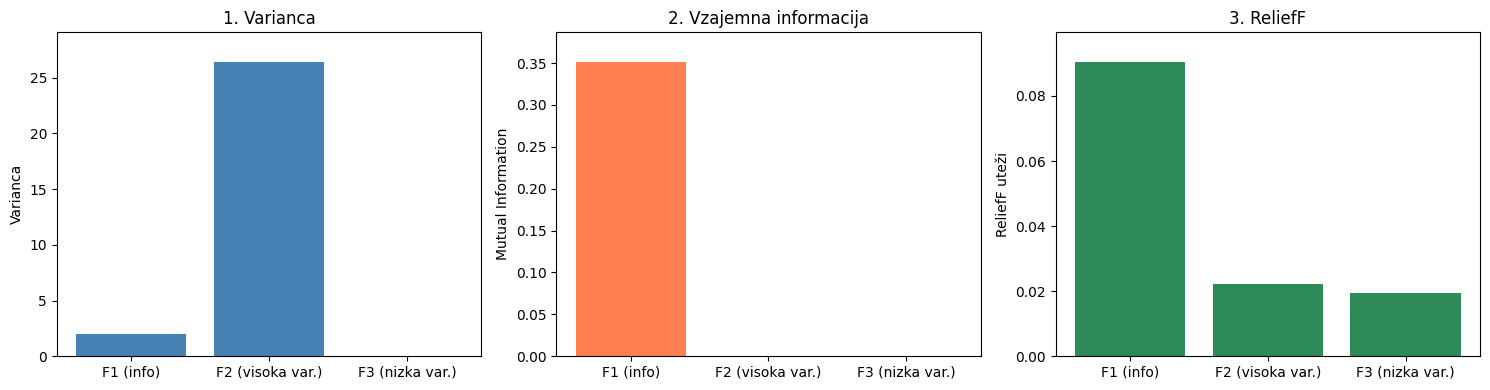

In [6]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

rng = np.random.default_rng(0)
n = 600
class_probs = [0.7, 0.2, 0.1]
y_data = rng.choice(3, size=n, p=class_probs)

class_means = np.array([0.0, 1.5, 3.0])
F1 = rng.normal(0, 1, n) + class_means[y_data]   # informativna, ločuje razrede
F2 = rng.normal(0, 5, n)                          # visoka varianca, neinformativna
F3 = rng.normal(0, 0.01, n)                       # nizka varianca, neinformativna
X_data = np.column_stack([F1, F2, F3])

feature_names = ["F1 (info)", "F2 (visoka var.)", "F3 (nizka var.)"]

# 1. Varianca
variance_scores = np.var(X_data, axis=0)

# 2. Mutual Information
mi_scores = mutual_info_classif(X_data, y_data, random_state=0)

# 3. ReliefF
feature_ranges = X_data.max(axis=0) - X_data.min(axis=0)
categorical_mask = np.array([False, False, False])

relieff_scores = relieff(X_data, y_data, n_iterations=n, k=10,
                         feature_ranges=feature_ranges,
                         categorical_mask=categorical_mask,
                         rng=np.random.default_rng(0))

# Risanje treh subplotov
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Subplot 1: Varianca
axes[0].bar(feature_names, variance_scores, color='steelblue')
axes[0].set_ylabel("Varianca")
axes[0].set_title("1. Varianca")
axes[0].set_ylim(0, max(variance_scores) * 1.1)

# Subplot 2: Mutual Information
axes[1].bar(feature_names, mi_scores, color='coral')
axes[1].set_ylabel("Mutual Information")
axes[1].set_title("2. Vzajemna informacija")
axes[1].set_ylim(0, max(mi_scores) * 1.1)

# Subplot 3: ReliefF
axes[2].bar(feature_names, relieff_scores, color='seagreen')
axes[2].set_ylabel("ReliefF uteži")
axes[2].set_title("3. ReliefF")
axes[2].set_ylim(0, max(relieff_scores) * 1.1)

plt.tight_layout()
plt.show()


### 2.d: Past interakcije — podatkovna množica XOR s štirimi spremenljivkami

Sestavimo sedaj bolj zahtevno podatkovno množico s štirimi napovednimi spremenljivkami:
- $F_1, F_2$: vsaka posebej je čisti šum ($\mathcal{N}(0, 1)$), a skupaj preko XOR vzorca popolnoma določita vrednost ciljne spremenljivke $y$ tako, da velja $y = 1$ natanko tedaj, ko sta $F_1$ in $F_2$ istega predznaka.
- $F_3$: neinformativni šum z visoko varianco.
- $F_4$: neinformativni šum z nizko varianco.

Na tej podatkovni množici ponovno poženi vse tri metode iz 2.c in vizualiziraj rezultate.

**Vprašanji:** 

- Zakaj pri ocenjevanju napovednih moči spremenljivk $F_1$ in $F_2$ odpove varianca in zakaj odpove vzajemna informacija?
- Opiši zakaj ReliefF napovednih moči spremenljivk $F_1$ in $F_2$ lahko prepozna oziroma identificiraj in opiši prednost tega pristopa pred drugima dvema.

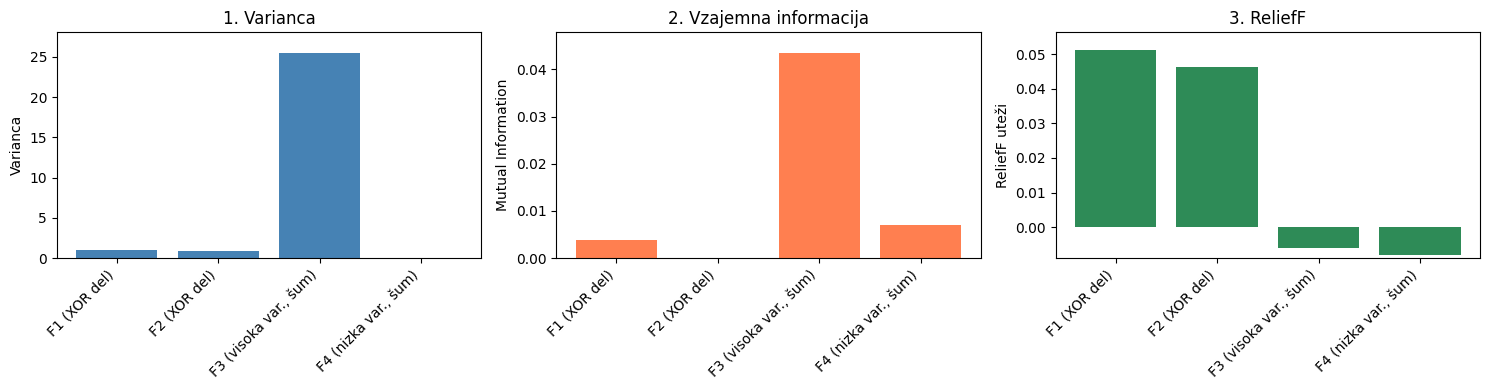

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

rng = np.random.default_rng(0)
n = 500
F1 = rng.normal(0, 1, n)
F2 = rng.normal(0, 1, n)
y_data = ((F1 * F2) > 0).astype(int)  # XOR: 1, če sta istega predznaka
F3 = rng.normal(0, 5, n)              # visoka varianca, neinformativna
F4 = rng.normal(0, 0.01, n)           # nizka varianca, neinformativna
X_data = np.column_stack([F1, F2, F3, F4])

feature_names = ["F1 (XOR del)", "F2 (XOR del)", "F3 (visoka var., šum)", "F4 (nizka var., šum)"]

# 1. Varianca
variance_scores = np.var(X_data, axis=0)

# 2. Mutual Information
mi_scores = mutual_info_classif(X_data, y_data, random_state=0)

# 3. ReliefF
feature_ranges = X_data.max(axis=0) - X_data.min(axis=0)
categorical_mask = np.array([False, False, False, False])

relieff_scores = relieff(X_data, y_data, n_iterations=n, k=10,
                         feature_ranges=feature_ranges,
                         categorical_mask=categorical_mask,
                         rng=np.random.default_rng(0))

# Helper to compute appropriate y-limits including negatives
def y_limits_for(scores, pad=0.1):
    mn = np.min(scores)
    mx = np.max(scores)
    if mn < 0:
        ymin = mn * (1 + pad)
    else:
        ymin = 0.0
    if mx > 0:
        ymax = mx * (1 + pad)
    else:
        ymax = 0.0
    # If both are zero (edge case), set a small range
    if ymin == 0.0 and ymax == 0.0:
        ymin, ymax = -0.1, 0.1
    return ymin, ymax

# Risanje treh subplotov
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Subplot 1: Varianca
axes[0].bar(range(len(feature_names)), variance_scores, color='steelblue')
axes[0].set_xticks(range(len(feature_names)))
axes[0].set_xticklabels(feature_names, rotation=45, ha='right')
axes[0].set_ylabel("Varianca")
axes[0].set_title("1. Varianca")
vmin, vmax = y_limits_for(variance_scores)
axes[0].set_ylim(vmin, vmax)

# Subplot 2: Mutual Information
axes[1].bar(range(len(feature_names)), mi_scores, color='coral')
axes[1].set_xticks(range(len(feature_names)))
axes[1].set_xticklabels(feature_names, rotation=45, ha='right')
axes[1].set_ylabel("Mutual Information")
axes[1].set_title("2. Vzajemna informacija")
vmin, vmax = y_limits_for(mi_scores)
axes[1].set_ylim(vmin, vmax)

# Subplot 3: ReliefF
axes[2].bar(range(len(feature_names)), relieff_scores, color='seagreen')
axes[2].set_xticks(range(len(feature_names)))
axes[2].set_xticklabels(feature_names, rotation=45, ha='right')
axes[2].set_ylabel("ReliefF uteži")
axes[2].set_title("3. ReliefF")
vmin, vmax = y_limits_for(relieff_scores)
axes[2].set_ylim(vmin, vmax)

plt.tight_layout()
plt.show()


**Odgovora:**
- Varianca odpove, ker meri samo razpršenost vrednosti posamezne spremenljivke, ne pa njene povezanosti s ciljno spremenljivko $y$. Zato lahko kot pomembno oceni spremenljivko z veliko varianco, čeprav je ta samo šum. V našem primeru je to $F_3$, ki ima največjo varianco, vendar ni informativna za napoved razreda. Spremenljivki $F_1$ in $F_2$ pa imata pomembnost zaradi XOR strukture, kjer razred ni odvisen od vsake posebej, ampak od njune kombinacije. Vzajemna informacija odpove zato, ker je uporabljena univariatno, torej ocenjuje $I(F_1;y)$ in $I(F_2;y)$ ločeno. Pri XOR problemu pa $F_1$ sama zase in $F_2$ sama zase ne povesta veliko o razredu; informacija se pokaže šele pri skupnem paru $(F_1,F_2)$.
- ReliefF lahko prepozna pomembnost $F_1$ in $F_2$, ker temelji na lokalnih primerjavah med bližnjimi primeri istega in različnih razredov. Pri XOR strukturi se pomembnost $F_1$ in $F_2$ pokaže šele skozi njuno kombinacijo, zato metode, ki gledajo vsako spremenljivko izolirano, odpovejo. ReliefF pa primerja bližnje primere v prostoru vseh spremenljivk in preverja, katere spremenljivke prispevajo k razlikovanju med razredi. Zato lahko zazna interakcijo med $F_1$ in $F_2$ ter jima dodeli visoki pozitivni uteži. Njegova prednost pred varianco je, da upošteva ciljno spremenljivko $y$, prednost pred univariatno vzajemno informacijo pa je, da lahko zazna tudi lokalne odvisnosti in interakcije med spremenljivkami.

### 2.e: Razprava

Odgovori na naslednji vprašanji:

1. Predstavljaj si, da podatkovni množici iz 2.d dodaš spremenljivko $F_5$, ki je natančna (ali skoraj natančna) kopija spremenljivke $F_1$. Kakšne uteži pričakuješ od ReliefF za $F_1$ in $F_5$? Je to dobro ali slabo za izbiro spremenljivk, če želimo na koncu uporabiti čim manj spremenljivk?

2. Kdaj (v kakšnih primerih) bi izbral vsakega od treh pristopov iz naloge 2.c?

**Odgovora:**
- Če je $F_5$ natančna ali skoraj natančna kopija $F_1$, pričakujemo, da bo ReliefF spremenljivkama $F_1$ in $F_5$ dodelil zelo podobni uteži, torej $w(F_1) \approx w(F_5)$. Razlog je, da imata spremenljivki skoraj enake vrednosti, zato pri lokalnih primerjavah med primeri prispevata enake ali zelo podobne razlike. To je dobro, če želimo zaznati spremenljivke z napovedno močjo, ker ReliefF pravilno prepozna, da obe nosita koristno informacijo. Slabo pa je, če želimo na koncu uporabiti čim manj spremenljivk, saj sta $F_1$ in $F_5$ redundantni. V takem primeru bi morali po ocenjevanju pomembnosti odstraniti eno izmed močno koreliranih spremenljivk ali uporabiti metodo, ki poleg pomembnosti upošteva tudi redundanco.
- Varianco bi izbrali kot preprost nenadzorovan filter, predvsem za odstranjevanje konstantnih ali skoraj konstantnih spremenljivk. Ni primerna kot glavna mera napovedne moči, ker ne upošteva ciljne spremenljivke $y$. Vzajemno informacijo bi izbrali, kadar želimo oceniti povezavo med posamezno spremenljivko in ciljem $y$, posebej če je povezava lahko nelinearna. Primerna je, kadar so spremenljivke same zase informativne, slabša pa pri interakcijah, kot je XOR. ReliefF bi izbrali, kadar pričakujemo lokalne odvisnosti ali interakcije med spremenljivkami. Njegova prednost je, da upošteva razrede in primerja bližnje primere istega ter različnih razredov, zato lahko zazna tudi spremenljivke, ki so pomembne šele v kombinaciji z drugimi.


## Naloga 3: Nelinearno krčenje razsežnosti in neuravnotežene množice

V tej nalogi se bomo hkrati soočali z dvema povezanima problemoma. Najprej bomo skrčili razsežnost podatkov s samokodirnikom in primerjali rezultate s PCA. Nato pa bomo vizualno ugotavljali, kako SMOTE vzorči nove primere in s tem pomaga pri uravnoteževanju porazdelitve vrednosti ciljne spremenljivke.

Za podatke bomo uporabili sklearnov `load_digits` — 1797 ročno napisanih števk velikosti $8 \times 8$ pikslov (64 napovednih spremenljivk).

### 3.a: Samokodirnik

Samokodirnike že poznaš z vaj — tukaj jih bomo uporabili kot nelinearno alternativo metodi analize glavnih komponent (PCA). Spomnimo se ključne razlike med PCA in samokodirnikom. Če sta kodirnik in dekodirnik linearna, samokodirnik preslika podatke v latentni nizkorazsežnostni prostor tako kot PCA. Z uporabo nelinearnih funkcij aktivacije v kodirniku in dekodirniku, se lahko samokodirnik nauči primere nelinearno transformirati v latentni prostor. Ta nelinearna transformacija je bistvo te naloge.

Dopolni razred `Autoencoder`, tako da bo implementiral kodirnik z arhitekturo `input_dim → 32 → 16 → latent_dim` in dekodirnik z zrcalno arhitekturo. V vseh plasteh, razen izhodni plasti dekodirnika, uporabi `nn.Tanh()`. V izhodni plasti dekodirnika pa uporabi `nn.Sigmoid()` (zato, da bodo vrednosti pikslov v intervalu $[0, 1]$).

In [4]:
import torch
import torch.nn as nn


class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.Tanh(),
            nn.Linear(32, 16),
            nn.Tanh(),
            nn.Linear(16, latent_dim),
            nn.Tanh()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.Tanh(),
            nn.Linear(16, 32),
            nn.Tanh(),
            nn.Linear(32, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z


def train_autoencoder(model, X, n_epochs=3000, lr=2e-3, verbose=True):
    """Učenje samokodirnika z MSE izgubo in Adam optimizatorjem."""
    if not torch.is_tensor(X):
        X = torch.tensor(X, dtype=torch.float32)
    else:
        X = X.float()

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        x_rec, z = model(X)
        loss = criterion(x_rec, X)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if verbose and (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch + 1}/{n_epochs}, loss = {loss.item():.6f}")

    return losses


# Hiter test
torch.manual_seed(0)
ae_test = Autoencoder(input_dim=64, latent_dim=2)
x_test = torch.rand(5, 64)
x_rec, z = ae_test(x_test)
print("Vhod:", x_test.shape, "→ latentni:", z.shape, "→ rekonstrukcija:", x_rec.shape)


Vhod: torch.Size([5, 64]) → latentni: torch.Size([5, 2]) → rekonstrukcija: torch.Size([5, 64])


### 3.b: Števke — PCA vs. samokodirnik

Naložimo podatkovno množico `sklearn.datasets.load_digits` in normalizirajmo vrednosti pikslov (napovednih spremenljivk) na interval $[0, 1]$ (delimo s 16, ker so vrednosti pikslov v intervalu $[0, 16]$).

Naredi naslednje:
1. Prikaži nekaj primerov števk (npr. po eno iz vsakega razreda).
2. Uporabi PCA za preslikavo podatkovne množice v dvodimenzionalni prostor.
3. Natreniraj samokodirnik z `latent_dim=2` in pridobi njegove dvodimenzionalne predstavitve primerov iz učne množice v latentnem prostoru.
4. Za vsako od teh dveh predstavitev nariši scatterplot enega ob drugem, kjer so točke pobarvane na osnovi števk, ki jih predstavljajo.

**Vprašanji:**
- Katera metoda bolje loči skupine primerov po razredih (števkah) in zakaj? Premisli kolikšno je najmanjše število komponent PCA, ki bi jih potrebovali zato, da dobro ločimo števke (razrede).
- Latentni prostor samokodirnika nikoli ni "prazen prostor": ko z dekodirnikom dekodiramo katero koli točko iz njega, dobimo nekakšno sliko, ki je videti kot števka (oziroma včasih kot kombinacija števk). Kako bi to lastnost izkoristili za generiranje novih primerov? Zakaj v originalnem 64-razsežnem prostoru slikovnih pik tak naivni pristop vzorčenja vrednosti 64 pikslov ne deluje (torej, zakaj v tem primeru večnimo ne bi dobili kombinacijo pikslov, kar bi tvorili nekaj, kar je podobno števki)?

**Odgovora:**
- Na podlagi dobljenih grafov samokodirnik bolje loči skupine primerov po števkah kot PCA. Pri PCA predstavitvi v $2D$ se veliko razredov prekriva, saj prvi dve PCA komponenti skupaj pojasnita samo približno $28.5\%$ variance. To pomeni, da se pri preslikavi iz $64$ dimenzij v $2$ dimenziji izgubi veliko informacij. Latentni prostor samokodirnika je bolj strukturiran, ker se samokodirnik nauči nelinearne predstavitve podatkov, medtem ko je PCA linearna metoda. Za dobro ločevanje števk s PCA dve komponenti nista dovolj; potrebovali bi več komponent, verjetno toliko, da bi ohranili vsaj $80\%$ ali $90\%$ variance. Točno število bi določili empirično s kumulativno pojasnjeno varianco ali s preverjanjem uspešnosti klasifikacije.
- Latentni prostor samokodirnika lahko uporabimo za generiranje novih primerov tako, da izberemo novo točko v latentnem prostoru in jo dekodiramo z dekodirnikom. Če izberemo točko med dvema obstoječima latentnima predstavitvama, lahko dobimo novo sliko, ki je podobna števki ali pa predstavlja kombinacijo števk. To deluje zato, ker se latentni prostor med učenjem oblikuje kot zgoščena in strukturirana predstavitev realnih slik števk. V originalnem $64$-razsežnem prostoru pikslov pa naivno vzorčenje ne deluje, ker večina naključnih kombinacij $64$ pikslov ne predstavlja smiselne števke, ampak šum. Smiselne slike števk ležijo samo na majhnem in strukturiranem delu celotnega prostora pikslov.


Število primerov: 1797, dimenzija: 64


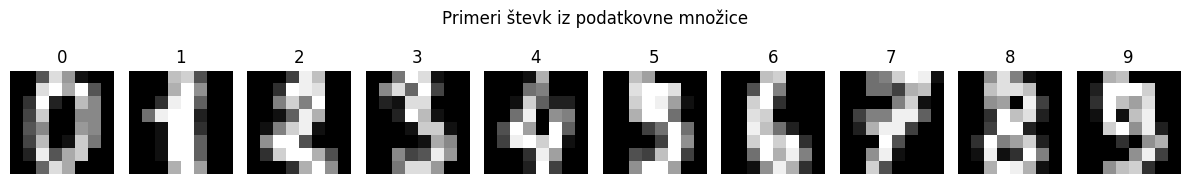

Delež pojasnjene variance prve PCA komponente: 0.1489059358406385
Delež pojasnjene variance druge PCA komponente: 0.13618771239635447
Skupaj pojasnjena varianca: 0.28509364823699296
Epoch 500/3000, loss = 0.049781
Epoch 1000/3000, loss = 0.036642
Epoch 1500/3000, loss = 0.031066
Epoch 2000/3000, loss = 0.028582
Epoch 2500/3000, loss = 0.027219
Epoch 3000/3000, loss = 0.026133


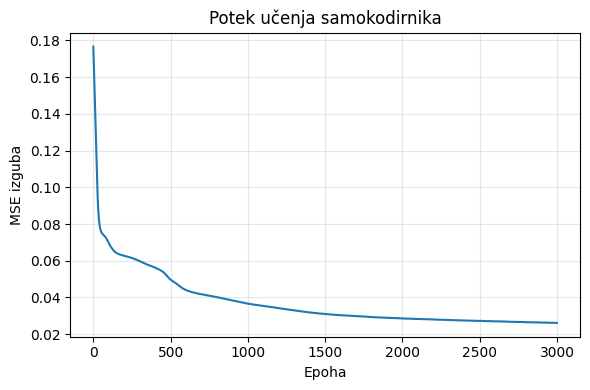

C:\Users\Brus\AppData\Local\Temp\ipykernel_25004\2472093153.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


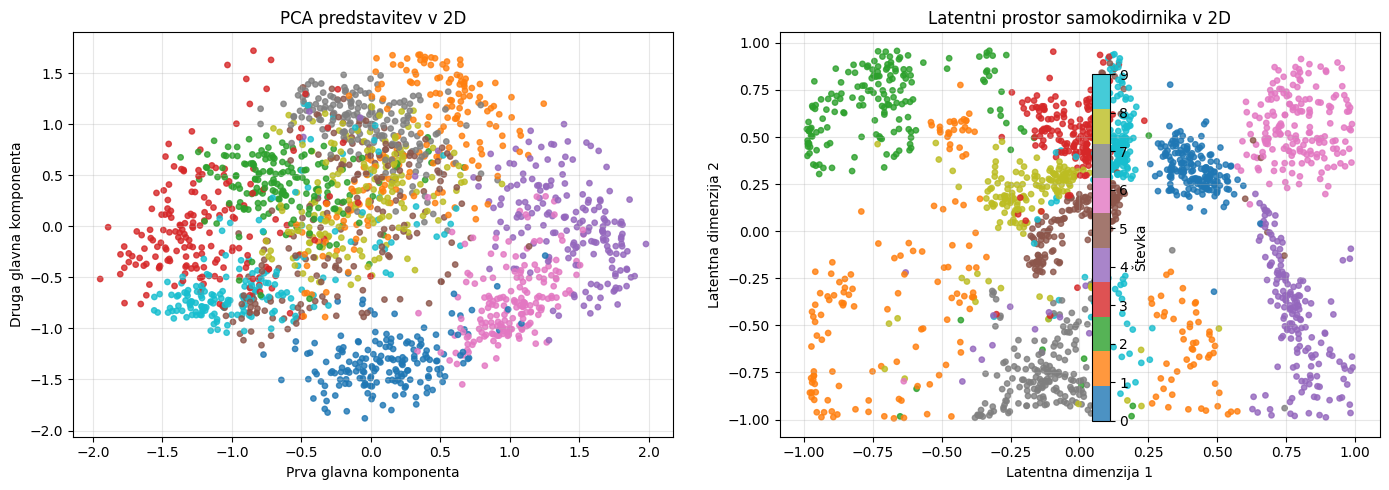

In [5]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from matplotlib.colors import BoundaryNorm


# =========================
# Podatki
# =========================

digits = load_digits()
X_digits = digits.data / 16.0       # piksli 0..16 -> 0..1
y_digits = digits.target

print(f"Število primerov: {X_digits.shape[0]}, dimenzija: {X_digits.shape[1]}")


# =========================
# 1. Prikaz nekaj primerov števk
# =========================

fig, axes = plt.subplots(1, 10, figsize=(12, 2))

for digit in range(10):
    idx = np.where(y_digits == digit)[0][0]
    img = X_digits[idx].reshape(8, 8)

    axes[digit].imshow(img, cmap="gray")
    axes[digit].set_title(str(digit))
    axes[digit].axis("off")

plt.suptitle("Primeri števk iz podatkovne množice")
plt.tight_layout()
plt.show()


# =========================
# 2. PCA preslikava v 2D prostor
# =========================

pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_digits)

print("Delež pojasnjene variance prve PCA komponente:", pca.explained_variance_ratio_[0])
print("Delež pojasnjene variance druge PCA komponente:", pca.explained_variance_ratio_[1])
print("Skupaj pojasnjena varianca:", np.sum(pca.explained_variance_ratio_))


# =========================
# 3. Učenje samokodirnika z latent_dim = 2
# =========================

torch.manual_seed(0)
np.random.seed(0)

input_dim = X_digits.shape[1]
latent_dim = 2

ae = Autoencoder(input_dim=input_dim, latent_dim=latent_dim)

losses = train_autoencoder(
    model=ae,
    X=X_digits,
    n_epochs=3000,
    lr=2e-3,
    verbose=True
)


# Graf poteka učenja
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("Epoha")
plt.ylabel("MSE izguba")
plt.title("Potek učenja samokodirnika")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Pridobimo 2D latentne predstavitve iz samokodirnika
ae.eval()

X_tensor = torch.tensor(X_digits, dtype=torch.float32)

with torch.no_grad():
    x_rec, z = ae(X_tensor)
    X_ae_2d = z.numpy()


# =========================
# 4. Scatterplot: PCA proti samokodirniku
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y_digits,
    cmap="tab10",
    s=15,
    alpha=0.8
)

axes[0].set_title("PCA predstavitev v 2D")
axes[0].set_xlabel("Prva glavna komponenta")
axes[0].set_ylabel("Druga glavna komponenta")
axes[0].grid(alpha=0.3)


scatter2 = axes[1].scatter(
    X_ae_2d[:, 0],
    X_ae_2d[:, 1],
    c=y_digits,
    cmap="tab10",
    s=15,
    alpha=0.8
)

axes[1].set_title("Latentni prostor samokodirnika v 2D")
axes[1].set_xlabel("Latentna dimenzija 1")
axes[1].set_ylabel("Latentna dimenzija 2")
axes[1].grid(alpha=0.3)


# Skupna legenda oziroma barvna lestvica za števke
cbar = fig.colorbar(scatter2, ax=axes, ticks=range(10), shrink=0.9)
cbar.set_label("Števka")

plt.tight_layout()
plt.show()

### 3.c: Neuravnoteženost in SMOTE — vizualno

Sedaj iz podatkovne množice števk sestavimo podatkovno množico za binarno klasifikacijo in v njej ustvarimo močno neuravnoteženost med razredoma takole. Izberemo dve podobni si števki (npr. 3 in 8) ter vzamemo zgolj 5 % primerov za eno od števk in vse primere za drugo števko. V tako dobljeni množici bo razmerje primerov v enem in drugem razredu približno $95\!:\!5$.

V tej nalogi se bomo osredotočili izključno na vizualizacijo manjšinskega razreda. Klasifikatorja ne treniramo: zanima nas, kako se porazdelitev vrednosti napovednih spremenljivk v dodanih primerih (sintetičnih primerih ali duplikatih) manjšinskega razreda ujemajo s pravo porazdelitvijo vrednosti napovednih spremenljivk v pravih primerih iz tega razreda. Slednjo ocenimo iz množice vseh pravih števk iz istega razreda, tudi tistimi, ki smo jih izpustili pri vzorčenju nove podatkovne množice.

Trije pristopi (uporabi knjižnico [imbalanced-learn](https://imbalanced-learn.org/)):
1. Brez popravkov — pustimo neuravnoteženo.
2. Naključno nadvzorčenje (`imblearn.over_sampling.RandomOverSampler`) — primere manjšinskega razreda preprosto podvajamo.
3. SMOTE (`imblearn.over_sampling.SMOTE`) — za vsak manjšinski primer poišče $k$ najbližjih sosedov istega razreda in generira sintetičen primer kot naključno interpolacijo:
$$x_{\text{nov}} = x_i + \lambda \cdot (x_{\text{sosed}} - x_i), \quad \lambda \sim \mathcal{U}(0, 1).$$

Naredi naslednje:
1. S samokodirnikom iz 3.b preslikaj v dvodimenzionalni latentni prostor naslednje primere:
   - vse prave primere manjšinskega razreda (kot referenca — to je porazdelitev, ki bi jo videli, če bi imeli vse podatke),
   - primere manjšinjskega razreda, ki smo jih vzorčili v novo podatkovno množico (tistih 5 %),
   - dodane primere (z naključnim vzorčenjem duplikatov in z uporabo SMOTE).
   Nariši tri scatter grafe enega ob drugem (vzorec / + duplilkati / + SMOTE) in jasno loči vse vrste točk, ki so za to množico aplikabilni.
2. Vizualiziraj nekaj primerov manjšinskega razreda kot $8 \times 8$ slike v štirih vrsticah: prave (neuporabljene), vzorčene, naključno vzorčeni duplikati, in sintetični SMOTE primeri.

**Vprašanji:**

- Pri SMOTE: ali so dodani sintetični primeri znotraj referenčne porazdelitve pravih manjšinskih primerov, ali izven nje? Kaj to pove o kakovosti novih sintetičnih primerov?
- SMOTE interpolira v originalnem 64-razsežnem prostoru slikovnih pik. Premisli: če bi pred SMOTE projecirali podatke v latentni prostor samokodirnika in šele tam interpolirali nove predstavitve, ki bi jih nato dekodirali nazaj v slike, bi pričakovali boljše ali slabše sintetične primere? Zakaj? (Namig: razmisli o drugem vprašanju iz 3.b — kaj se zgodi, če interpoliramo med slikama, ki ležita v različnih delih mnogoterosti smiselnih števk?)

In [7]:
!pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



**Odgovora:**
- Na podlagi latentnega prikaza so dodani sintetični primeri SMOTE večinoma znotraj referenčne porazdelitve pravih primerov manjšinskega razreda $8$. Zelene točke ležijo predvsem v območju, kjer so tudi sive točke, ki predstavljajo vse prave osmice. To pomeni, da SMOTE ni ustvaril izrazito nenaravnih primerov daleč stran od prave porazdelitve, zato so sintetični primeri načeloma smiselni. Vendar pa smo v neuravnoteženi množici obdržali samo $9$ od $174$ pravih osmic, zato SMOTE ustvarja nove primere samo iz zelo majhnega dela manjšinskega razreda. Posledično sintetični primeri dobro pokrijejo predvsem območja okoli vzorčenih osmic in interpolacije med njimi, ne pa nujno celotne raznolikosti pravih osmic.
- SMOTE v latentnem prostoru bi lahko dal boljše sintetične primere, ker je latentni prostor samokodirnika naučen kot zgoščena in bolj strukturirana predstavitev smiselnih slik števk. Interpolacija med bližnjimi latentnimi predstavitvami bi zato lahko ostala bližje mnogoterosti realnih osmic kot interpolacija neposredno v originalnem $64$-razsežnem prostoru pikslov. V originalnem prostoru lahko linearna interpolacija med slikami povzroči zamegljene ali manj naravne slike. Vendar latentni SMOTE ni vedno boljši: če interpoliramo med primeri, ki ležijo v različnih delih mnogoterosti smiselnih števk, lahko dekodirnik ustvari nejasno ali mešano sliko, ki ni dobra osmica. Zato bi latentni SMOTE pričakovali kot boljši predvsem takrat, ko je latentni prostor dobro naučen in interpoliramo med res podobnimi primeri.

Vzorec: [183   9] (vzorčili smo 9 od 174 pravih '8')
Brez popravkov: [183   9]
RandomOverSampler: [183 183] | dodani duplikati: 174
SMOTE: [183 183] | dodani sintetični primeri: 174


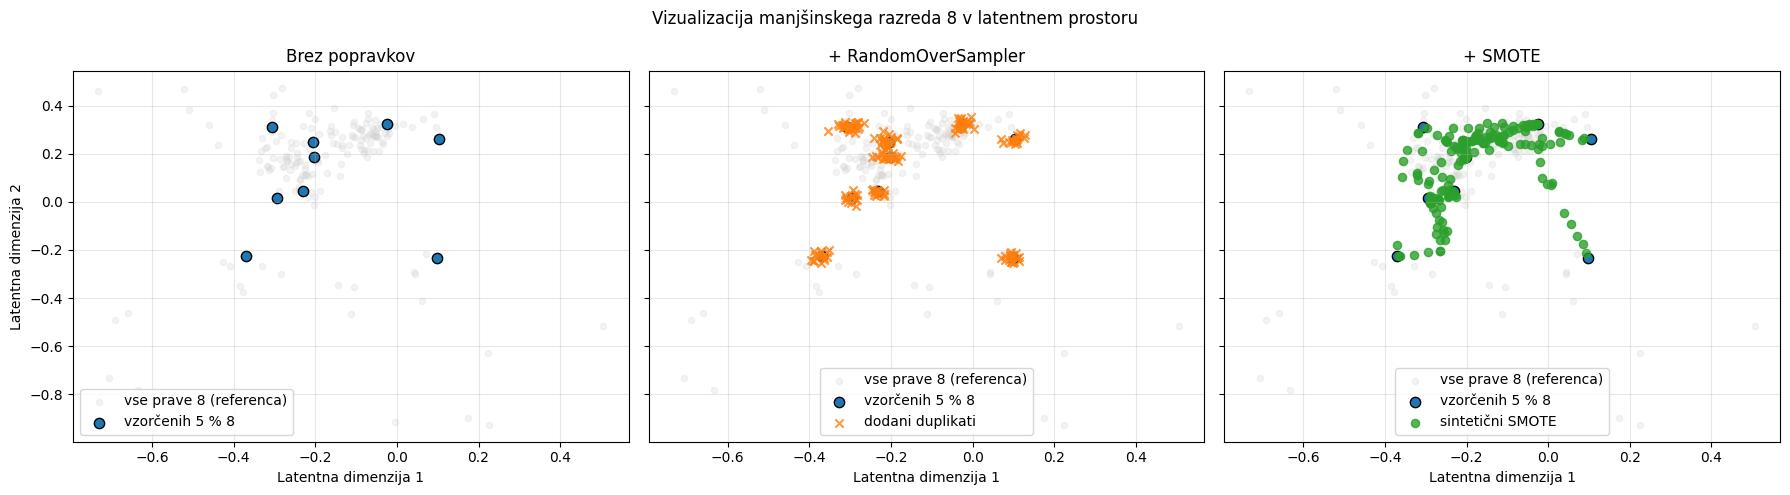

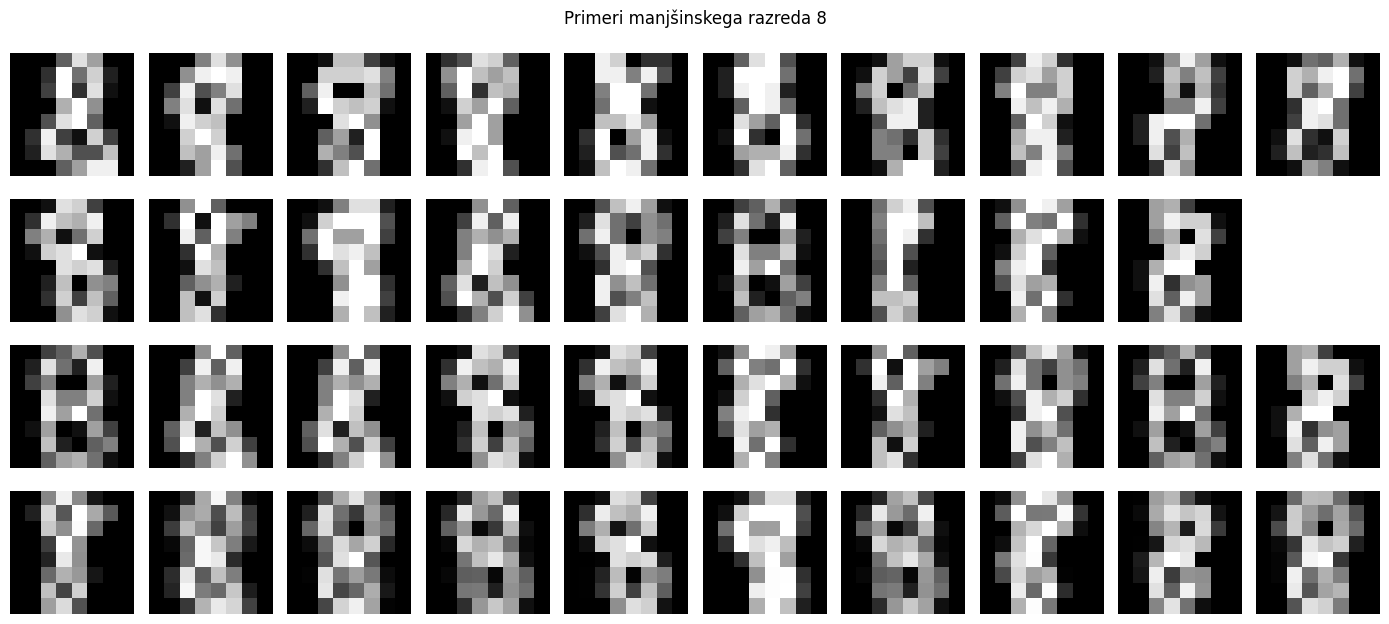

In [8]:
from imblearn.over_sampling import RandomOverSampler, SMOTE

# 1. Izberi dva razreda (3 in 8) in ustvari neuravnoteženost; sledimo, katere prave 8 smo izpustili
CLASS_A, CLASS_B = 3, 8                  # CLASS_B bo manjšina
mask = np.isin(y_digits, [CLASS_A, CLASS_B])
X_pair = X_digits[mask]
y_pair = (y_digits[mask] == CLASS_B).astype(int)

rng = np.random.default_rng(0)
idx_majority = np.where(y_pair == 0)[0]
idx_minority_full = np.where(y_pair == 1)[0]
n_keep = int(0.05 * len(idx_majority) / 0.95)
idx_minority_keep = rng.choice(idx_minority_full, size=n_keep, replace=False)
idx_minority_heldout = np.setdiff1d(idx_minority_full, idx_minority_keep)
idx_keep = np.concatenate([idx_majority, idx_minority_keep])

X_imb = X_pair[idx_keep]
y_imb = y_pair[idx_keep]
print(f"Vzorec: {np.bincount(y_imb)} (vzorčili smo {n_keep} od {len(idx_minority_full)} pravih '{CLASS_B}')")

# ============================================================
# Pomožna funkcija: preslikava v 2D latentni prostor samokodirnika
# ============================================================

def encode_with_autoencoder(model, X):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32)

    with torch.no_grad():
        x_rec, z = model(X_tensor)

    return z.detach().cpu().numpy()


# ============================================================
# 2. Pripravimo referenčne, vzorčene in izpuščene manjšinske primere
# ============================================================

# Vsi pravi primeri manjšinskega razreda CLASS_B, torej vse prave osmice
X_minority_full = X_pair[idx_minority_full]

# Tisti manjšinski primeri, ki smo jih dejansko obdržali v neuravnoteženi množici
X_minority_keep = X_pair[idx_minority_keep]

# Pravi manjšinski primeri, ki smo jih pri vzorčenju izpustili
X_minority_heldout = X_pair[idx_minority_heldout]


# ============================================================
# 3. Brez popravkov, RandomOverSampler in SMOTE
# ============================================================

# 1) Brez popravkov: uporabimo X_imb, y_imb

# 2) Naključno nadvzorčenje z duplikati
ros = RandomOverSampler(random_state=0)
X_ros, y_ros = ros.fit_resample(X_imb, y_imb)

# RandomOverSampler shrani indekse originalnih primerov, iz katerih je sestavil novo množico
ros_added_source_indices = ros.sample_indices_[len(X_imb):]
X_ros_added = X_imb[ros_added_source_indices]

# 3) SMOTE
# k_neighbors mora biti manjši od števila manjšinskih primerov
k_smote = min(5, n_keep - 1)

smote = SMOTE(random_state=0, k_neighbors=k_smote)
X_smote, y_smote = smote.fit_resample(X_imb, y_imb)

# Pri SMOTE so novi sintetični primeri dodani za originalnimi primeri
X_smote_added = X_smote[len(X_imb):]


print("Brez popravkov:", np.bincount(y_imb))
print("RandomOverSampler:", np.bincount(y_ros), "| dodani duplikati:", len(X_ros_added))
print("SMOTE:", np.bincount(y_smote), "| dodani sintetični primeri:", len(X_smote_added))


# ============================================================
# 4. Preslikava v latentni prostor
# ============================================================

Z_minority_full = encode_with_autoencoder(ae, X_minority_full)
Z_minority_keep = encode_with_autoencoder(ae, X_minority_keep)
Z_minority_heldout = encode_with_autoencoder(ae, X_minority_heldout)

Z_ros_added = encode_with_autoencoder(ae, X_ros_added)
Z_smote_added = encode_with_autoencoder(ae, X_smote_added)


# Pri duplikatih so točke na popolnoma istih koordinatah kot originali,
# zato jih za prikaz rahlo zamaknemo. To je samo za vizualizacijo.
rng_plot = np.random.default_rng(0)
Z_ros_added_plot = Z_ros_added + rng_plot.normal(0, 0.015, size=Z_ros_added.shape)


# ============================================================
# 5. Trije scatter grafi
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# -------------------------
# Graf 1: brez popravkov
# -------------------------
axes[0].scatter(
    Z_minority_full[:, 0],
    Z_minority_full[:, 1],
    s=20,
    alpha=0.25,
    color="lightgray",
    label=f"vse prave {CLASS_B} (referenca)"
)

axes[0].scatter(
    Z_minority_keep[:, 0],
    Z_minority_keep[:, 1],
    s=55,
    color="tab:blue",
    edgecolor="black",
    label=f"vzorčenih 5 % {CLASS_B}"
)

axes[0].set_title("Brez popravkov")
axes[0].set_xlabel("Latentna dimenzija 1")
axes[0].set_ylabel("Latentna dimenzija 2")
axes[0].grid(alpha=0.3)
axes[0].legend()


# -------------------------
# Graf 2: RandomOverSampler
# -------------------------
axes[1].scatter(
    Z_minority_full[:, 0],
    Z_minority_full[:, 1],
    s=20,
    alpha=0.25,
    color="lightgray",
    label=f"vse prave {CLASS_B} (referenca)"
)

axes[1].scatter(
    Z_minority_keep[:, 0],
    Z_minority_keep[:, 1],
    s=55,
    color="tab:blue",
    edgecolor="black",
    label=f"vzorčenih 5 % {CLASS_B}"
)

axes[1].scatter(
    Z_ros_added_plot[:, 0],
    Z_ros_added_plot[:, 1],
    s=35,
    color="tab:orange",
    marker="x",
    alpha=0.8,
    label="dodani duplikati"
)

axes[1].set_title("+ RandomOverSampler")
axes[1].set_xlabel("Latentna dimenzija 1")
axes[1].grid(alpha=0.3)
axes[1].legend()


# -------------------------
# Graf 3: SMOTE
# -------------------------
axes[2].scatter(
    Z_minority_full[:, 0],
    Z_minority_full[:, 1],
    s=20,
    alpha=0.25,
    color="lightgray",
    label=f"vse prave {CLASS_B} (referenca)"
)

axes[2].scatter(
    Z_minority_keep[:, 0],
    Z_minority_keep[:, 1],
    s=55,
    color="tab:blue",
    edgecolor="black",
    label=f"vzorčenih 5 % {CLASS_B}"
)

axes[2].scatter(
    Z_smote_added[:, 0],
    Z_smote_added[:, 1],
    s=35,
    color="tab:green",
    alpha=0.8,
    label="sintetični SMOTE"
)

axes[2].set_title("+ SMOTE")
axes[2].set_xlabel("Latentna dimenzija 1")
axes[2].grid(alpha=0.3)
axes[2].legend()


plt.suptitle(f"Vizualizacija manjšinskega razreda {CLASS_B} v latentnem prostoru")
plt.tight_layout()
plt.show()


# ============================================================
# 6. Prikaz slik: prave neuporabljene, vzorčene, duplikati, SMOTE
# ============================================================

def show_image_rows(rows, row_titles, n_cols=10):
    fig, axes = plt.subplots(len(rows), n_cols, figsize=(1.4 * n_cols, 1.6 * len(rows)))

    rng_img = np.random.default_rng(1)

    for r, (X_row, title) in enumerate(zip(rows, row_titles)):
        if len(X_row) == 0:
            for c in range(n_cols):
                axes[r, c].axis("off")
            axes[r, 0].set_ylabel(title, rotation=0, labelpad=45, va="center")
            continue

        if len(X_row) >= n_cols:
            chosen = rng_img.choice(len(X_row), size=n_cols, replace=False)
        else:
            chosen = np.arange(len(X_row))

        for c in range(n_cols):
            ax = axes[r, c]
            ax.axis("off")

            if c < len(chosen):
                img = X_row[chosen[c]].reshape(8, 8)
                ax.imshow(img, cmap="gray", vmin=0, vmax=1)

        axes[r, 0].set_ylabel(title, rotation=0, labelpad=55, va="center")

    plt.suptitle(f"Primeri manjšinskega razreda {CLASS_B}")
    plt.tight_layout()
    plt.show()


rows = [
    X_minority_heldout,
    X_minority_keep,
    X_ros_added,
    X_smote_added
]

row_titles = [
    "prave\nneuporabljene",
    "vzorčene",
    "duplikati",
    "SMOTE"
]

show_image_rows(rows, row_titles, n_cols=10)


## Naloga 4: Odprta naloga

V datoteki `dn3_cracked.csv` je podana podatkovna množica, kjer primeri ustrezajo študentom. Tvoja naloga je sestaviti napovedni model, ki glede na smiselno izbrano metriko čim bolje napove, ali je študent študij končal, ga še vedno opravlja, ali je s študijem prenehal (to so vrednosti v zadnjem stolpcu z naslovom `Target`).

Celoten postopek in vse poskuse (tudi neuspešne) zabeleži in o njih poročaj.

> Pozor: Ne predpostavljaj, da so podatki čisti. Izbira mere uspešnosti, postopek delitve podatkov in obravnava razredne neuravnoteženosti so del naloge — vse svoje odločitve dobro premisli in tudi pisno utemelji v oddani rešitvi.

Podatkovna množica vsebuje naslednje spremenljivke:

- Zakonski stan: kategorični
- Vrsta vloge: kategoričen
- Vrstni red vloge: int
- Tečaj: kategoričen
- Prisotnost podnevi/zvečer: kategorična
- Prejšnja kvalifikacija: kategorična
- Prejšnja kvalifikacija (ocena): float
- Državljanstvo: kategorialno
- Materina kvalifikacija: kategorična
- Očetova kvalifikacija: kategorična
- Poklic matere: kategoričen
- Poklic očeta: kategoričen
- Ocena pri vpisu: float
- Preseljen: kategorično
- Posebne izobraževalne potrebe: kategorično
- Dolžnik: kategorično
- Šolnine do datuma: kategorično
- Spol: kategorično
- Zadnje tri številke študentske izkaznice: int
- Štipendist: kategorično
- Starost ob vpisu: int
- Tujec: kategorično
- Učne enote 1. semester (priznane): int
- Učne enote 1. semester (vpisane): int
- Učne enote 1. semester (ocene): int
- Učne enote 1. semester (odobrene): int
- Učne enote 1. semester (ocena): float
- Učne enote 1. semester (brez ocen): int
- Učne enote 2. semester (priznane): int
- Učne enote 2. semester (vpisane): int
- Učne enote 2. semester (ocene): int
- Učne enote 2. semester (odobrene): int
- Učne enote 2. semester (ocena): float
- Učne enote 2. semester (brez ocen): int
- Stopnja brezposelnosti: float
- Stopnja inflacije: float
- BDP: float
- Standardiziran rezultat sprejemnega testa: float
- Indeks socioekonomskega statusa: float
- Anketni rezultat zadovoljstva: float
- Povprečna ocena srednje šole (normalizirana): float
- Indeks oddaljenosti od fakultete: float
- Mesečni dohodek staršev (z-score): float
- Rezultat psihološkega testa A: float
- Rezultat psihološkega testa B: float
- Indeks delovne obremenitve: float
- Število ur učenja na teden (z-score): float
- Indeks digitalne pismenosti: float
- Rezultat preverjanja angleščine: float
- Ocena motivacijskega pisma: float
- Indeks zdravstvenega stanja: float
- Rezultat testa logičnega sklepanja: float
- Številka prijave: int
- Šifra mentorja: int
- Številka razreda v srednji šoli: int
- Poštna številka: int
- Šifra študijskega programa: int
- Ciljna vrednost (`Target`): kategoričen
